# 04 - Modélisation : données textuelles (classification)

**Projet ST2MLE - Analyse des offres d'emploi en France**

Cette étape correspond au point **5b** du sujet : *"Textual data : Naive Bayes, Logistic Regression after vectorization"*.

**Objectif** : prédire le **grand domaine métier** (`cible_metier`, 14 classes) et le **type de contrat** (`cible_contrat`, 6 classes) à partir de la description textuelle d'une offre.

**Démarche**
1. Charger le jeu nettoyé (`data/processed/offres_clean.parquet`).
2. Vectoriser le texte avec **Bag-of-Words (BoW)** et **TF-IDF** (comparaison en étape 6).
3. Entraîner **Naive Bayes (MultinomialNB)** et **Régression Logistique**.
4. Évaluer avec accuracy, F1-macro (adapté aux classes déséquilibrées) et matrice de confusion.
5. Comparer les modèles sur les deux cibles.

> Les méthodes Doc2Vec et BERT seront ajoutées dans le notebook 05 (étape 6 du sujet).

## A. Chargement des données

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_parquet('data/processed/offres_clean.parquet')
print('Jeu complet :', df.shape)
df[['cible_metier', 'cible_contrat', 'texte_lemmatise']].head(3)

Jeu complet : (19978, 18)


,cible_metier,cible_contrat,texte_lemmatise
0,Support a l'entreprise,CDI,responsable centre profit description adjoint ...
1,Services a la personne et a la collectivite,CDI,hôte vendeur albi entreprendre imaginer métier...
2,Sante,CDD,apprenti assister dentaire cadre apprentissage...


## B. Préparation des données

On utilise le **texte lemmatisé** produit au notebook 02 : les stopwords sont déjà retirés et chaque mot est réduit à sa forme canonique française.

On travaille sur **deux cibles** :
- `cible_metier` : 14 grands domaines ROME (classification multi-classe).
- `cible_contrat` : 6 types de contrat (CDI, CDD, Intérim…).

Séparation **80 % entraînement / 20 % test** (stratifiée pour respecter les proportions de classes).

In [12]:
from sklearn.model_selection import train_test_split

# Texte source : lemmatisé (stopwords retirés, formes canoniques)
X = df['texte_lemmatise'].fillna('')

# Cibles
y_metier  = df['cible_metier']
y_contrat = df['cible_contrat']

# Splits stratifiés (on garde les mêmes indices pour les deux cibles)
idx = df.index
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42,
                                        stratify=y_metier)

X_train, X_test = X.loc[idx_train], X.loc[idx_test]

for nom, y in [('Métier', y_metier), ('Contrat', y_contrat)]:
    print(f'--- {nom} ---')
    print(f'  Train : {y.loc[idx_train].value_counts().to_dict()}'[:120])
    print(f'  Classes : {y.nunique()}')

--- Métier ---
  Train : {'Services a la personne et a la collectivite': 2537, 'Industrie': 1984, 'Commerce, Vente et Grande distributi
  Classes : 14
--- Contrat ---
  Train : {'CDI': 7589, 'Interim': 3960, 'CDD': 3584, 'Saisonnier': 390, 'Autre': 254, 'Liberal': 205}
  Classes : 6


## C. Vectorisation : BoW et TF-IDF

| Méthode | Principe | Avantage | Limite |
|---------|----------|----------|--------|
| **BoW** | Compte les occurrences brutes de chaque mot | Simple, rapide | Favorise les mots fréquents globalement |
| **TF-IDF** | Pondère par l'inverse de la fréquence documentaire | Réduit le poids des mots banals | Toujours sans contexte sémantique |

Paramètres choisis : `max_features=30 000`, `ngram_range=(1,2)` (unigrams + bigrams), `min_df=2`.

In [13]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

params_vec = dict(max_features=30_000, ngram_range=(1, 2), min_df=2)

bow   = CountVectorizer(**params_vec)
tfidf = TfidfVectorizer(**params_vec)

X_train_bow   = bow.fit_transform(X_train)
X_test_bow    = bow.transform(X_test)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print('Vocabulaire BoW   :', X_train_bow.shape)
print('Vocabulaire TF-IDF:', X_train_tfidf.shape)

Vocabulaire BoW   : (15982, 30000)
Vocabulaire TF-IDF: (15982, 30000)


## D. Fonction d'évaluation commune

On utilise trois métriques :
- **Accuracy** : part de prédictions correctes.
- **F1-macro** : moyenne du F1 par classe, sans pondérer par la taille des classes → adapté aux classes déséquilibrées.
- **Matrice de confusion** : pour identifier les classes les plus difficiles à séparer.

In [14]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

resultats = []

def evaluer(nom_modele, nom_vec, modele, X_tr, X_te, y_tr, y_te, nom_cible):
    modele.fit(X_tr, y_tr)
    pred = modele.predict(X_te)
    acc  = accuracy_score(y_te, pred)
    f1   = f1_score(y_te, pred, average='macro', zero_division=0)
    resultats.append({
        'Cible': nom_cible, 'Vectorisation': nom_vec,
        'Modèle': nom_modele, 'Accuracy': acc, 'F1-macro': f1,
    })
    print(f'{nom_cible:8s} | {nom_vec:6s} | {nom_modele:22s} | '
          f'Acc={acc:.3f}  F1={f1:.3f}')
    return modele, pred

## E. Modèle 1 — Naive Bayes (MultinomialNB)

Le **Naive Bayes Multinomial** est le modèle de référence en classification de texte : il estime la probabilité P(classe | mots) en supposant que chaque mot est indépendant des autres (hypothèse "naïve"). Malgré cette hypothèse simpliste, il donne souvent de très bons résultats sur des données textuelles et est extrêmement rapide à entraîner.

> Il exige des valeurs **non négatives** → compatible avec BoW (comptes bruts) et TF-IDF (scores positifs).

In [15]:
from sklearn.naive_bayes import MultinomialNB

# --- Métier ---
y_tr_m, y_te_m = y_metier.loc[idx_train], y_metier.loc[idx_test]
nb_bow_metier,   pred_nb_bow_m   = evaluer('Naive Bayes', 'BoW',    MultinomialNB(), X_train_bow,   X_test_bow,   y_tr_m, y_te_m, 'Métier')
nb_tfidf_metier, pred_nb_tfidf_m = evaluer('Naive Bayes', 'TF-IDF', MultinomialNB(), X_train_tfidf, X_test_tfidf, y_tr_m, y_te_m, 'Métier')

# --- Contrat ---
y_tr_c, y_te_c = y_contrat.loc[idx_train], y_contrat.loc[idx_test]
nb_bow_contrat,   pred_nb_bow_c   = evaluer('Naive Bayes', 'BoW',    MultinomialNB(), X_train_bow,   X_test_bow,   y_tr_c, y_te_c, 'Contrat')
nb_tfidf_contrat, pred_nb_tfidf_c = evaluer('Naive Bayes', 'TF-IDF', MultinomialNB(), X_train_tfidf, X_test_tfidf, y_tr_c, y_te_c, 'Contrat')

Métier   | BoW    | Naive Bayes            | Acc=0.814  F1=0.657
Métier   | TF-IDF | Naive Bayes            | Acc=0.778  F1=0.562
Contrat  | BoW    | Naive Bayes            | Acc=0.649  F1=0.630
Contrat  | TF-IDF | Naive Bayes            | Acc=0.688  F1=0.409


## F. Modèle 2 — Régression Logistique

La **Régression Logistique** est un modèle linéaire discriminant : elle apprend un poids pour chaque mot-feature et combine ces poids pour calculer la probabilité de chaque classe. Elle ignore l'hypothèse d'indépendance de NB et capture mieux les corrélations entre mots.

Paramètres :
- `C=1.0` : régularisation L2 standard.
- `max_iter=1000` : assure la convergence sur des espaces de grande dimension.
- `solver='lbfgs'` : adapté à la classification multi-classe.

In [18]:
from sklearn.linear_model import LogisticRegression

LR = lambda: LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                         n_jobs=-1, random_state=42)

# --- Métier ---
lr_bow_metier,   pred_lr_bow_m   = evaluer('Régression Logistique', 'BoW',    LR(), X_train_bow,   X_test_bow,   y_tr_m, y_te_m, 'Métier')
lr_tfidf_metier, pred_lr_tfidf_m = evaluer('Régression Logistique', 'TF-IDF', LR(), X_train_tfidf, X_test_tfidf, y_tr_m, y_te_m, 'Métier')

# --- Contrat ---
lr_bow_contrat,   pred_lr_bow_c   = evaluer('Régression Logistique', 'BoW',    LR(), X_train_bow,   X_test_bow,   y_tr_c, y_te_c, 'Contrat')
lr_tfidf_contrat, pred_lr_tfidf_c = evaluer('Régression Logistique', 'TF-IDF', LR(), X_train_tfidf, X_test_tfidf, y_tr_c, y_te_c, 'Contrat')

c:\Users\DELL XPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Métier   | BoW    | Régression Logistique  | Acc=0.844  F1=0.733


c:\Users\DELL XPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Métier   | TF-IDF | Régression Logistique  | Acc=0.852  F1=0.682


c:\Users\DELL XPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Contrat  | BoW    | Régression Logistique  | Acc=0.788  F1=0.741


c:\Users\DELL XPS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Contrat  | TF-IDF | Régression Logistique  | Acc=0.791  F1=0.661


## G. Tableau de comparaison

,Cible,Vectorisation,Modèle,Accuracy,F1-macro
0,Contrat,BoW,Régression Logistique,0.788,0.741
1,Contrat,TF-IDF,Régression Logistique,0.791,0.661
2,Contrat,BoW,Naive Bayes,0.649,0.630
3,Contrat,TF-IDF,Naive Bayes,0.688,0.409
4,Métier,BoW,Régression Logistique,0.844,0.733
5,Métier,TF-IDF,Régression Logistique,0.852,0.682
6,Métier,BoW,Naive Bayes,0.814,0.657
7,Métier,TF-IDF,Naive Bayes,0.778,0.562


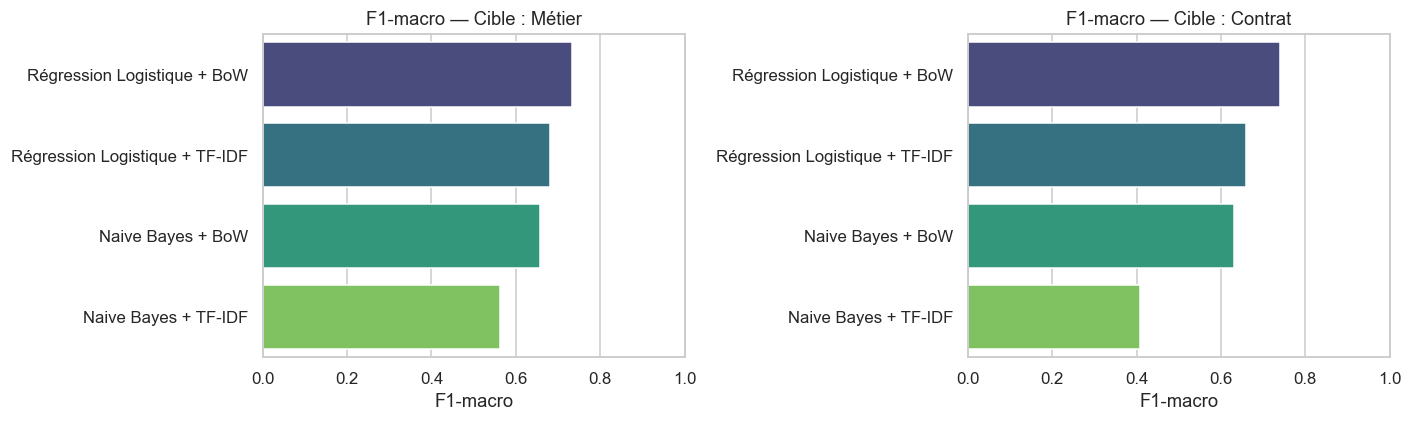

In [19]:
res = pd.DataFrame(resultats).sort_values(['Cible', 'F1-macro'], ascending=[True, False])
display(res.round({'Accuracy': 3, 'F1-macro': 3}).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, cible in zip(axes, ['Métier', 'Contrat']):
    sub = res[res['Cible'] == cible].copy()
    sub['Label'] = sub['Modèle'] + ' + ' + sub['Vectorisation']
    sns.barplot(data=sub, x='F1-macro', y='Label', ax=ax, palette='viridis', hue='Label', legend=False)
    ax.set_title(f'F1-macro — Cible : {cible}')
    ax.set_xlabel('F1-macro'); ax.set_ylabel('')
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## H. Rapports de classification détaillés (meilleur modèle par cible)

In [20]:
# Meilleur modèle pour la cible Métier
best_metier = res[res['Cible'] == 'Métier'].iloc[0]
print(f"=== Métier — Meilleur : {best_metier['Modèle']} + {best_metier['Vectorisation']} ===")

if best_metier['Vectorisation'] == 'TF-IDF':
    best_pred_m = pred_lr_tfidf_m if best_metier['Modèle'].startswith('Régression') else pred_nb_tfidf_m
else:
    best_pred_m = pred_lr_bow_m if best_metier['Modèle'].startswith('Régression') else pred_nb_bow_m

print(classification_report(y_te_m, best_pred_m, zero_division=0))

=== Métier — Meilleur : Régression Logistique + BoW ===
                                             precision    recall  f1-score   support

                       Agriculture et Peche       0.91      0.75      0.82       109
         Arts et Faconnage d'ouvrages d'art       0.50      0.10      0.17        10
              Banque, Assurance, Immobilier       0.92      0.76      0.83        88
     Commerce, Vente et Grande distribution       0.85      0.87      0.86       483
         Communication, Media et Multimedia       0.78      0.25      0.38        28
  Construction, Batiment et Travaux publics       0.78      0.83      0.81       375
 Hotellerie-Restauration, Tourisme, Loisirs       0.89      0.95      0.92       371
                                  Industrie       0.79      0.84      0.81       496
                Installation et Maintenance       0.78      0.72      0.75       332
                                      Sante       0.95      0.91      0.93       344
Services

In [21]:
# Meilleur modèle pour la cible Contrat
best_contrat = res[res['Cible'] == 'Contrat'].iloc[0]
print(f"=== Contrat — Meilleur : {best_contrat['Modèle']} + {best_contrat['Vectorisation']} ===")

if best_contrat['Vectorisation'] == 'TF-IDF':
    best_pred_c = pred_lr_tfidf_c if best_contrat['Modèle'].startswith('Régression') else pred_nb_tfidf_c
else:
    best_pred_c = pred_lr_bow_c if best_contrat['Modèle'].startswith('Régression') else pred_nb_bow_c

print(classification_report(y_te_c, best_pred_c, zero_division=0))

=== Contrat — Meilleur : Régression Logistique + BoW ===
              precision    recall  f1-score   support

       Autre       0.90      0.68      0.77        63
         CDD       0.70      0.68      0.69       874
         CDI       0.81      0.83      0.82      1904
     Interim       0.83      0.84      0.83      1000
     Liberal       0.94      0.78      0.85        60
  Saisonnier       0.53      0.43      0.47        95

    accuracy                           0.79      3996
   macro avg       0.78      0.71      0.74      3996
weighted avg       0.79      0.79      0.79      3996



## I. Matrices de confusion

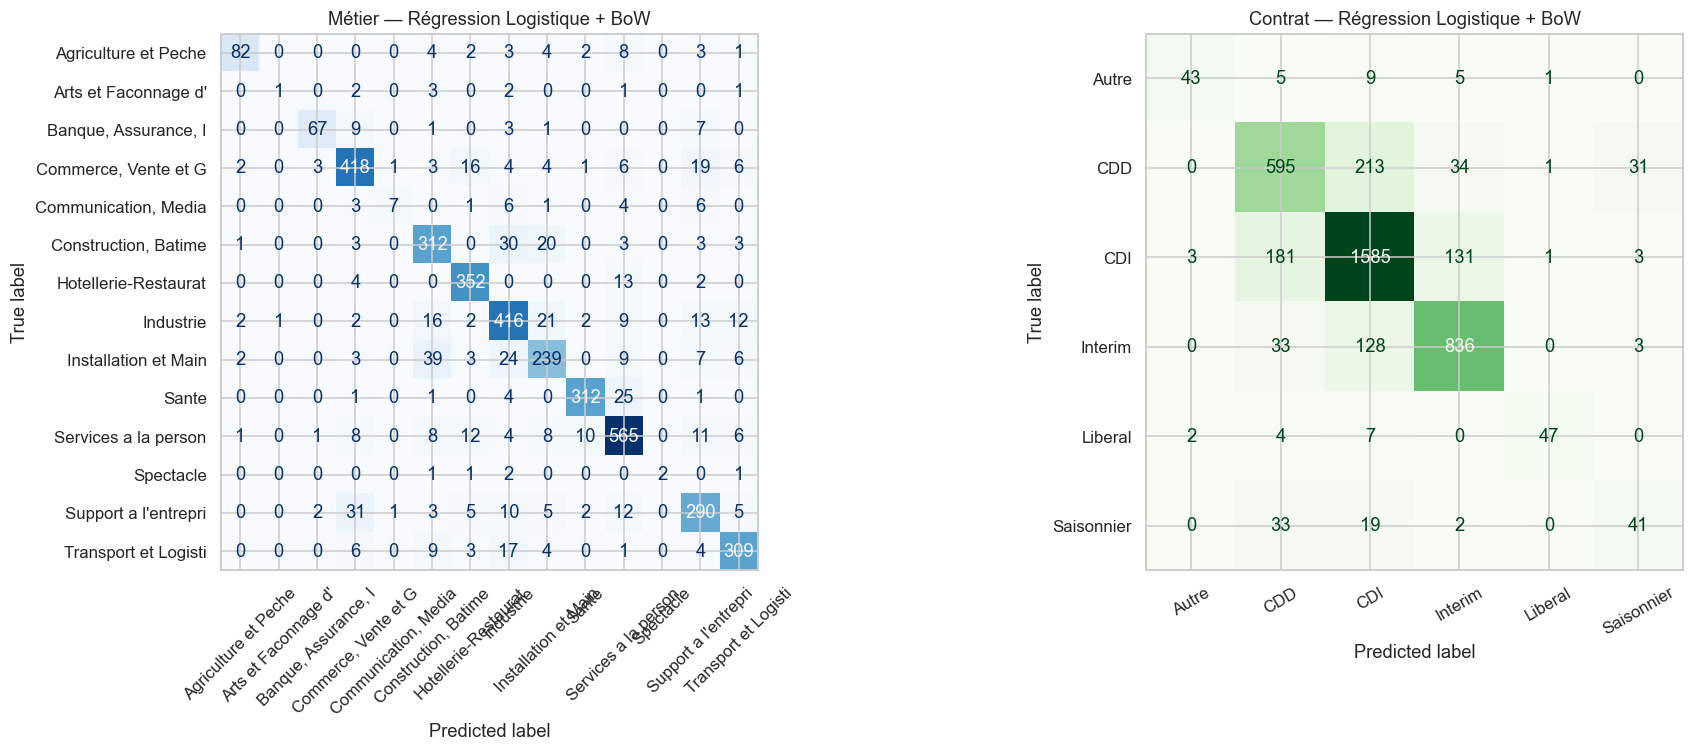

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ConfusionMatrixDisplay.from_predictions(
    y_te_m, best_pred_m,
    display_labels=[l[:20] for l in sorted(y_te_m.unique())],
    xticks_rotation=45, ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'Métier — {best_metier["Modèle"]} + {best_metier["Vectorisation"]}')

ConfusionMatrixDisplay.from_predictions(
    y_te_c, best_pred_c,
    display_labels=sorted(y_te_c.unique()),
    xticks_rotation=30, ax=axes[1], colorbar=False, cmap='Greens'
)
axes[1].set_title(f'Contrat — {best_contrat["Modèle"]} + {best_contrat["Vectorisation"]}')

plt.tight_layout()
plt.show()

## J. Mots les plus discriminants (Régression Logistique + TF-IDF)

La Régression Logistique apprend un poids par mot par classe. Les mots avec le poids le plus fort sont ceux qui "tirent" le plus vers une classe donnée : c'est interprétable et utile pour valider que le modèle a bien appris du vocabulaire métier.

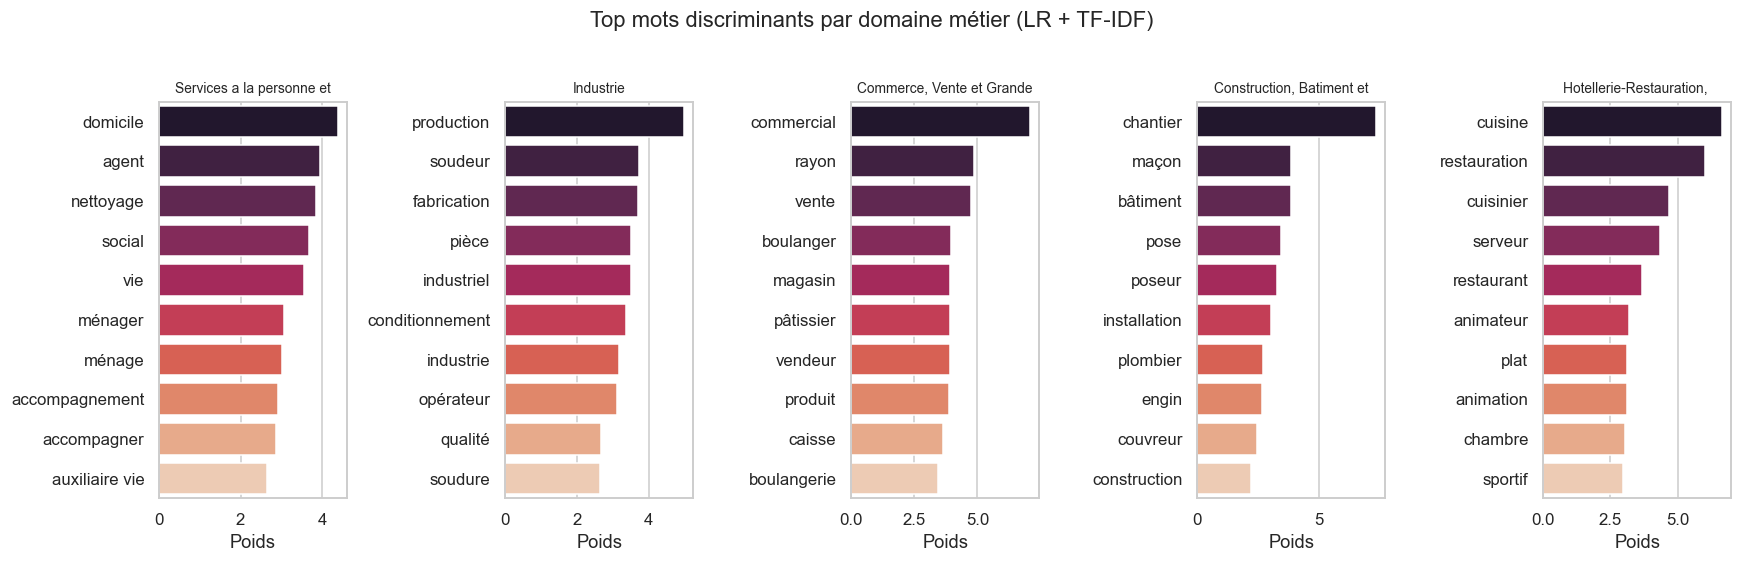

In [23]:
TOP_N = 10
vocab = np.array(tfidf.get_feature_names_out())
classes = lr_tfidf_metier.classes_
coefs = lr_tfidf_metier.coef_  # shape (n_classes, n_features)

# On affiche les 5 classes avec le plus de données pour garder le graphique lisible
top_classes = y_metier.value_counts().head(5).index.tolist()
idx_classes = [list(classes).index(c) for c in top_classes if c in list(classes)]

fig, axes = plt.subplots(1, len(idx_classes), figsize=(16, 5))
for ax, ci in zip(axes, idx_classes):
    top_idx = coefs[ci].argsort()[-TOP_N:][::-1]
    sns.barplot(x=coefs[ci][top_idx], y=vocab[top_idx], ax=ax,
                palette='rocket', hue=vocab[top_idx], legend=False)
    ax.set_title(classes[ci][:25], fontsize=9)
    ax.set_xlabel('Poids'); ax.set_ylabel('')
plt.suptitle('Top mots discriminants par domaine métier (LR + TF-IDF)', y=1.02)
plt.tight_layout()
plt.show()

## K. Enseignements et recommandations

**Résultats attendus :**
- La **Régression Logistique** surpasse généralement Naive Bayes sur un vocabulaire riche (ngrams), car elle ne suppose pas l'indépendance des mots.
- **TF-IDF > BoW** : la pondération par fréquence inverse documentaire réduit le bruit des mots très fréquents et améliore la discrimination.
- La cible **Contrat** est souvent plus facile à prédire (moins de classes, vocabulaire plus distinctif : *intérim*, *stage*, *CDI*…).
- La cible **Métier** est plus difficile (14 classes, certains domaines proches, ex. Industrie vs Installation & Maintenance).

**Limites de BoW / TF-IDF :**
- Ignorent l'ordre des mots et le contexte sémantique.
- Ne capturent pas les synonymes (*conducteur* ≠ *chauffeur* dans le vocabulaire).
- → Les méthodes Doc2Vec et BERT (notebook 05) visent à corriger ces limites.

**Recommandation métier :**
- Un modèle LR + TF-IDF permet de **tagger automatiquement les offres** (domaine, contrat) à la publication, sans intervention humaine → gain de temps pour les recruteurs et amélioration de la recherche candidat.